In [19]:
import matplotlib.pyplot as plt
import copy
import re
import numpy as np
from numpy import *
import pandas as pd
# Of the following charts, the ones with IID are based on the multikrumAgg aggregation alg., the ones non-IID are based on medianAgg aggregation alg.

In [20]:
retlog = "log.log"
acc = {}
mean_acc = {}
loss = {}
mean_loss = {}

num_client = 100
num_client_list = [num_client]
partition_type_list = ['iid', 'dirichlet']
min_ratio_presence_list = [1.0, 0.7, 0.5, 0.25]
dirichlet_alpha_list = [0.1, 0.5, 1.0]

num_tip_list = [5,4,3,2]
sim_type_list = ["[Sync_FL]","[Async_FL]","[Central_Sequential]","[Central_RandOrder]"]
for num_tip in num_tip_list:
    sim_type_list.append("[DAGFL_RandTips_alg.]-"+f"{num_tip}")
sim_type_list.append("[DAGFL_GS_alg.]")
sim_type_list.reverse()

for num_clients in num_client_list:
    acc[num_clients]={}
    mean_acc[num_clients] = {}
    loss[num_clients] = {}
    mean_loss[num_clients] = {}
    for partition_type in partition_type_list:
        acc[num_clients][partition_type]={}
        mean_acc[num_clients][partition_type]={}
        loss[num_clients][partition_type]={}
        mean_loss[num_clients][partition_type]={}
        for min_ratio_presence in min_ratio_presence_list:
            acc[num_clients][partition_type][min_ratio_presence] = {}
            mean_acc[num_clients][partition_type][min_ratio_presence] = {}
            loss[num_clients][partition_type][min_ratio_presence] = {}
            mean_loss[num_clients][partition_type][min_ratio_presence] = {}
            for dirichlet_alpha in dirichlet_alpha_list:
                acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]={}
                mean_acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]={}
                loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]={}
                mean_loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]={}
                for sim_type in sim_type_list:
                    acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type]=[]
                    mean_acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type]=[]
                    loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type]=[]
                    mean_loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type]=[]

# Delete unused parameter composition
for num_clients in num_client_list:
    for partition_type in partition_type_list:
        if partition_type == 'iid':
            for min_ratio_presence in min_ratio_presence_list:
                for dirichlet_alpha in [0.5, 1.0]:
                    del acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]
                    del mean_acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]
                    del loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]
                    del mean_loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]

        for min_ratio_presence in min_ratio_presence_list:
            if min_ratio_presence == 1.0:
                for dirichlet_alpha in acc[num_clients][partition_type][min_ratio_presence]:
                    del acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]["[Async_FL]"]
                    del mean_acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]["[Async_FL]"]
                    del loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]["[Async_FL]"]
                    del mean_loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]["[Async_FL]"]
            if min_ratio_presence < 1.0:
                for dirichlet_alpha in acc[num_clients][partition_type][min_ratio_presence]:
                    del acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]["[Sync_FL]"]
                    del mean_acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]["[Sync_FL]"]
                    del loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]["[Sync_FL]"]
                    del mean_loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]["[Sync_FL]"]

with open(retlog,'r') as f:
    flag = 0
    for line in f:
        line = line.rstrip()
        # read the settings of the simulation
        if line.startswith("["):
            flag=1
            markers=re.split('-',line)
            # get name of iidtype, simtype, attack type
            sim_type=markers[0]
            partition_type=markers[1]
            num_clients=int(markers[4].split('_')[2])
            min_ratio_presence=float(markers[5].split('_')[3])
            dirichlet_alpha=float(markers[6].split('_')[2])
            seed=int(markers[7].split('_')[1])
            # print(f"sim_type:{sim_type}, partition_type:{partition_type}, num_clients:{num_clients},min_ratio_presence:{min_ratio_presence}, dirichlet_alpha:{dirichlet_alpha}, seed:{seed}")
            if sim_type == '[DAGFL_RandTips_alg.]':
                num_tip= markers[8].split('_')[3]
                # tmp= markers[8].split('_')[2]
                # num_tip= tmp.split('=')[1]
                sim_type = "[DAGFL_RandTips_alg.]-"+ num_tip
        else:
            # only record the accuracy
            if flag == 1:
                acc_record = line.split(',')
                accuracies = []
                for _acc in acc_record:
                    accuracies.append(float(_acc))
                # print(f"num_clients:{num_clients},partition_type:{partition_type}, min_ratio_presence:{min_ratio_presence}, dirichlet_alpha:{dirichlet_alpha},  sim_type:{sim_type}, seed:{seed}")
                acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type].append(accuracies)
            if flag == 2:
                loss_record = line.split(',')
                losses = []
                for _loss in loss_record:
                    losses.append(float(_loss))
                loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type].append(losses)
            flag += 1
            flag = flag % 3

In [21]:
# get average accuracy
for num_clients in acc:
    for partition_type in acc[num_clients]:
        for min_ratio_presence in acc[num_clients][partition_type]:
            for dirichlet_alpha in acc[num_clients][partition_type][min_ratio_presence]:
                for sim_type in acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]:
                    if len(acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type])>0:
                        ret_array = np.array(acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type])
                        mean_acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type]=np.average(ret_array, axis=0)
                    else:
                        mean_acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type] = np.array([])
                    if len(loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type])>0:
                        ret_array = np.array(loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type])
                        mean_loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type]=np.average(ret_array, axis=0)
                    else:
                        mean_loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type] = np.array([])


In [22]:
# print average accuracy
import copy
for num_clients in acc:
    for partition_type in acc[num_clients]:
        for min_ratio_presence in acc[num_clients][partition_type]:
            for dirichlet_alpha in acc[num_clients][partition_type][min_ratio_presence]:
                for sim_type in acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]:
                    # print(f"sim_type:{sim_type}, partition_type:{partition_type}, num_clients:{num_clients},min_ratio_presence:{min_ratio_presence}, dirichlet_alpha:{dirichlet_alpha}, seed:{seed}")
                    # label = f"sim_type:{sim_type}, partition_type:{partition_type}, num_clients:{num_clients},min_ratio_presence:{min_ratio_presence}, dirichlet_alpha:{dirichlet_alpha}"
                    label = (f"sim_type:{sim_type}-{partition_type}-num_local_epoch_1-mnist-num_clients_{num_client}-min_ratio_presence_{min_ratio_presence}-dirichlet_alpha_{dirichlet_alpha}")
                    # print(label)
                    x = mean_acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type]
                    if x.size >0:
                    # if x.shape != ():
                        num = len(acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type])
                        print(f"{label}\t{x[0]}\t{x[-1]} \t Repeated simulations: \t {num}")

sim_type:[DAGFL_GS_alg.]-iid-num_local_epoch_1-mnist-num_clients_100-min_ratio_presence_1.0-dirichlet_alpha_0.1	0.1003	0.555 	 Repeated simulations: 	 1
sim_type:[DAGFL_RandTips_alg.]-2-iid-num_local_epoch_1-mnist-num_clients_100-min_ratio_presence_1.0-dirichlet_alpha_0.1	0.1003	0.5402 	 Repeated simulations: 	 1
sim_type:[DAGFL_RandTips_alg.]-3-iid-num_local_epoch_1-mnist-num_clients_100-min_ratio_presence_1.0-dirichlet_alpha_0.1	0.1002	0.5597 	 Repeated simulations: 	 1
sim_type:[DAGFL_RandTips_alg.]-4-iid-num_local_epoch_1-mnist-num_clients_100-min_ratio_presence_1.0-dirichlet_alpha_0.1	0.1003	0.5649 	 Repeated simulations: 	 1
sim_type:[DAGFL_RandTips_alg.]-5-iid-num_local_epoch_1-mnist-num_clients_100-min_ratio_presence_1.0-dirichlet_alpha_0.1	0.1003	0.5674 	 Repeated simulations: 	 1
sim_type:[Central_RandOrder]-iid-num_local_epoch_1-mnist-num_clients_100-min_ratio_presence_1.0-dirichlet_alpha_0.1	0.4985	0.6127 	 Repeated simulations: 	 1
sim_type:[Central_Sequential]-iid-num_loc

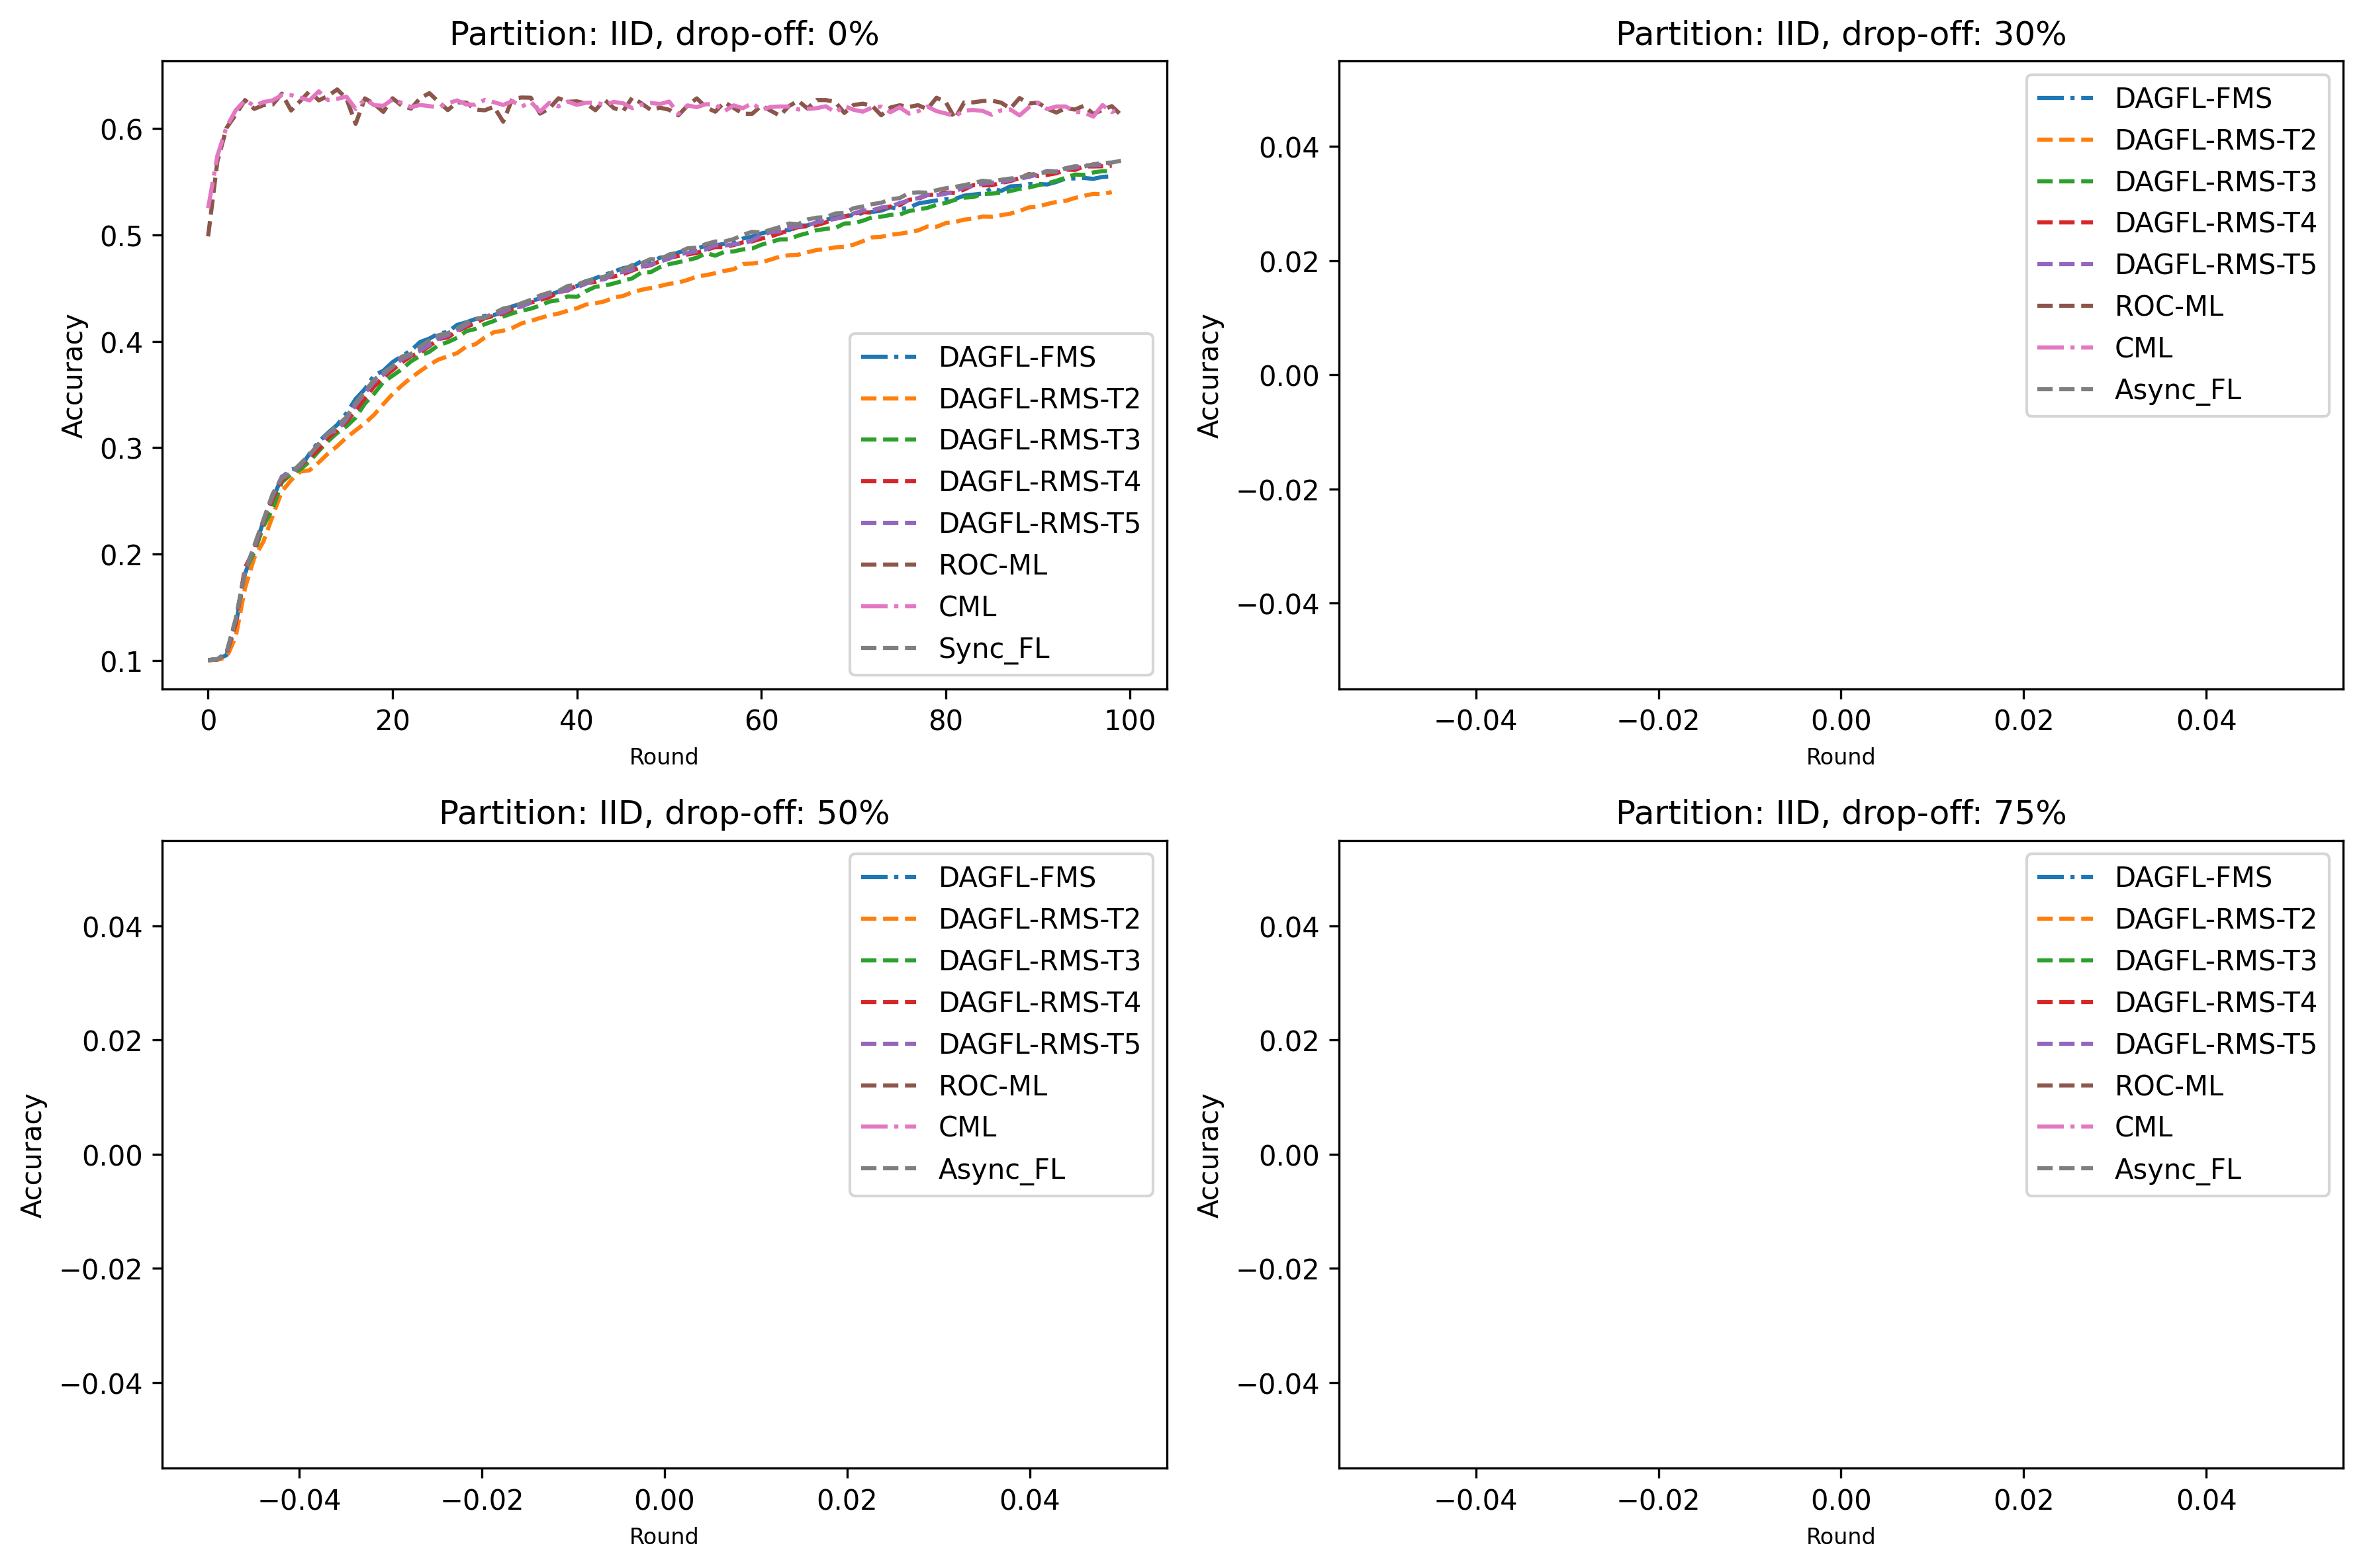

In [23]:
# Draw four together
plt.rcParams['figure.figsize'] = (10, 6)
# Draw IID
for num_clients in acc:
    for partition_type in ["iid"]:
        # Create a 2x2 grid of subplots
        fig, axes = plt.subplots(2, 2, figsize=(12,8), dpi=300)
        axes = axes.flatten()
        cnt_subplt = 0
        for min_ratio_presence in acc[num_clients][partition_type]:
            for dirichlet_alpha in acc[num_clients][partition_type][min_ratio_presence]:
                for sim_type in acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]:
                    label_texts = {
                        "[DAGFL_GS_alg.]":"DAGFL-FMS",
                        "[DAGFL_RandTips_alg.]-2":"DAGFL-RMS-T2",
                        "[DAGFL_RandTips_alg.]-3":"DAGFL-RMS-T3",
                        "[DAGFL_RandTips_alg.]-4":"DAGFL-RMS-T4",
                        "[DAGFL_RandTips_alg.]-5":"DAGFL-RMS-T5",
                        "[Central_RandOrder]": "ROC-ML",
                        "[Central_Sequential]": "CML",
                        "[Sync_FL]": "Sync_FL",
                        "[Async_FL]": "Async_FL"
                    }
                    linestyles = {
                        "[DAGFL_GS_alg.]":"-.",
                        "[DAGFL_RandTips_alg.]-2":"--",
                        "[DAGFL_RandTips_alg.]-3":"--",
                        "[DAGFL_RandTips_alg.]-4":"--",
                        "[DAGFL_RandTips_alg.]-5":"--",
                        "[Central_RandOrder]": "--",
                        "[Central_Sequential]": "-.",
                        "[Sync_FL]": "--",
                        "[Async_FL]": "--"
                    }
                    if partition_type == 'iid':
                        # title = f"partition: {partition_type}, min_ratio_presence:{min_ratio_presence}"
                        do = 1-min_ratio_presence
                        title = f"Partition: IID, drop-off: {do:.0%}"
                    else:
                        do = 1-min_ratio_presence
                        da_type = {0.1:"strongly non-IID", 0.5:"moderately non-IID", 1.0:"weakly non-IID"}
                        title = f"Partition: {da_type[dirichlet_alpha]}, drop-off: {do:.0%}"
                        # title = f"Partition: non-IID, D_alpha:{da_type[dirichlet_alpha]}, drop-off: {do:.0%}"
                        # title = f"partition: {partition_type}, D_alpha:{dirichlet_alpha},min_ratio_presence:{min_ratio_presence}"
                    y = mean_acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type][:199]
                    # plt.plot(y, linestyle=linestyles[sim_type], marker=markers[sim_type],label= label_texts[sim_type])  # Default x-values: [0, 1, 2, 3, 4]
                    # plt.plot(y, linestyle=linestyles[sim_type], label= label_texts[sim_type])  # Default x-values: [0, 1, 2, 3, 4]
                    x = np.arange(len(y))

                    axes[cnt_subplt].plot(x ,y, linestyle=linestyles[sim_type], label= label_texts[sim_type])  # Default x-values: [0, 1, 2, 3, 4]
                    axes[cnt_subplt].set_title(title)
                    axes[cnt_subplt].set_xlabel("Round",fontsize=8)
                    axes[cnt_subplt].set_ylabel("Accuracy")
                    axes[cnt_subplt].legend()

            cnt_subplt +=1
        plt.tight_layout()
        # plt.legend()
        plt.show()


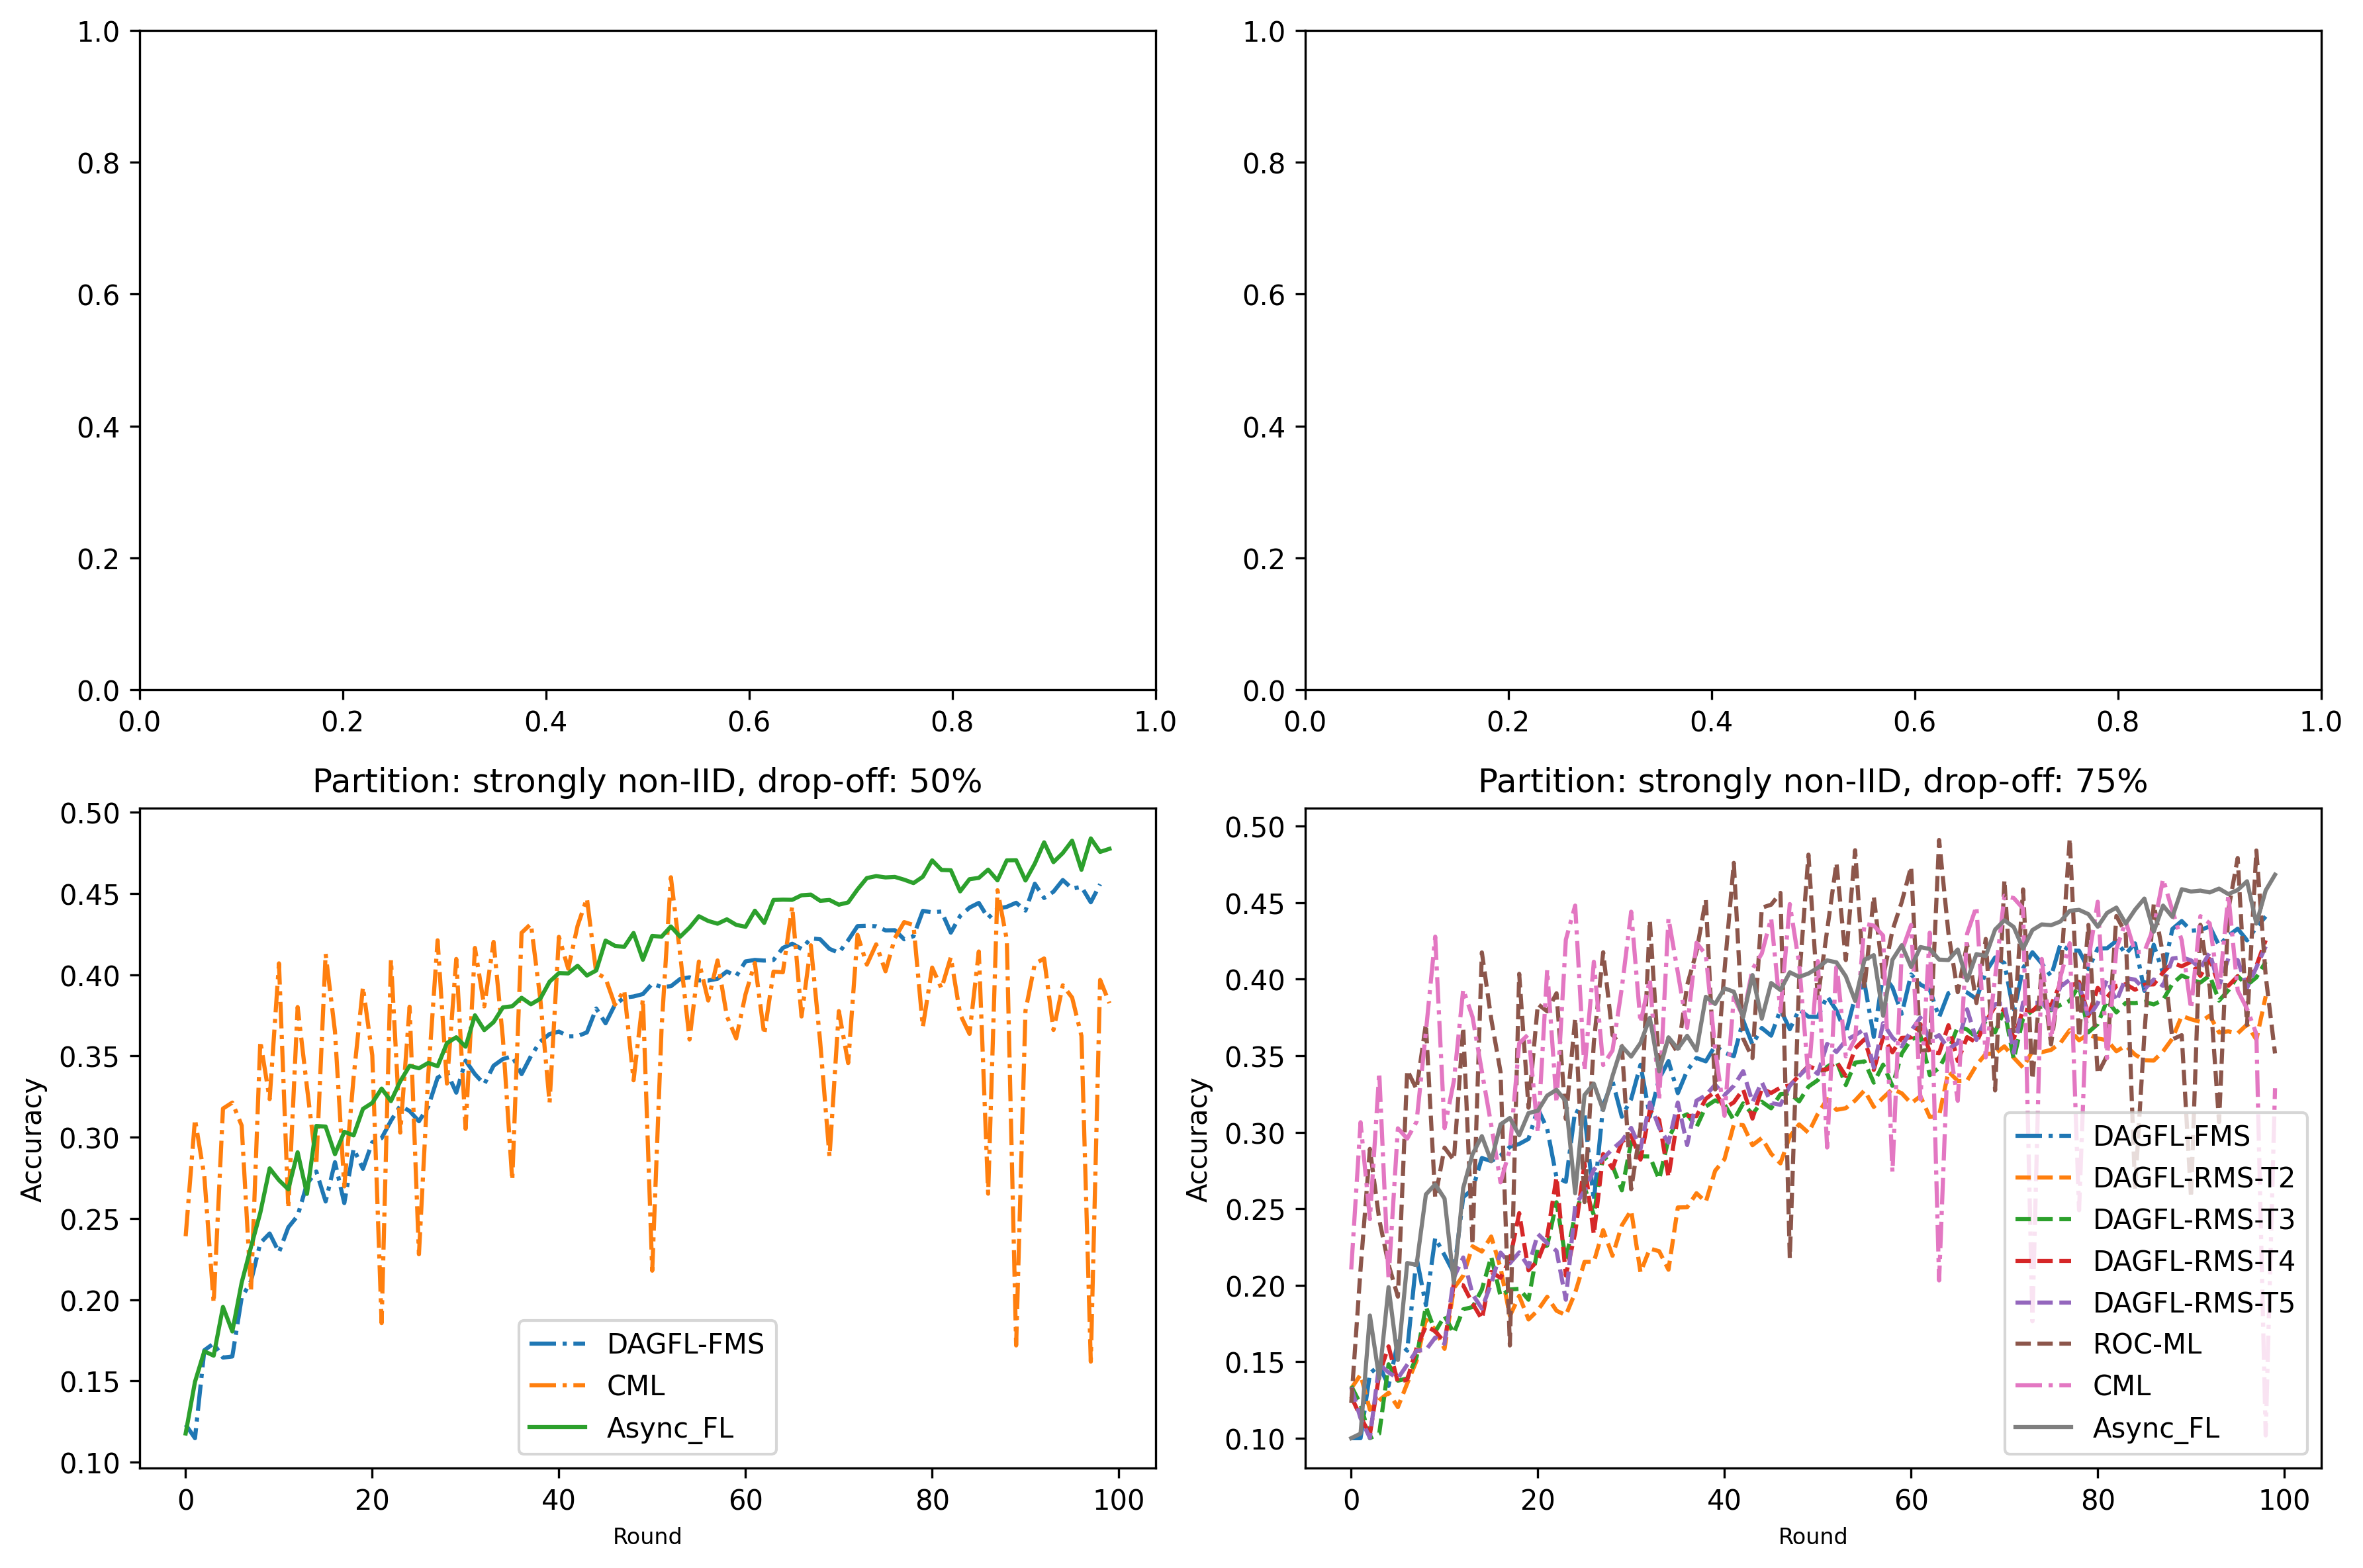

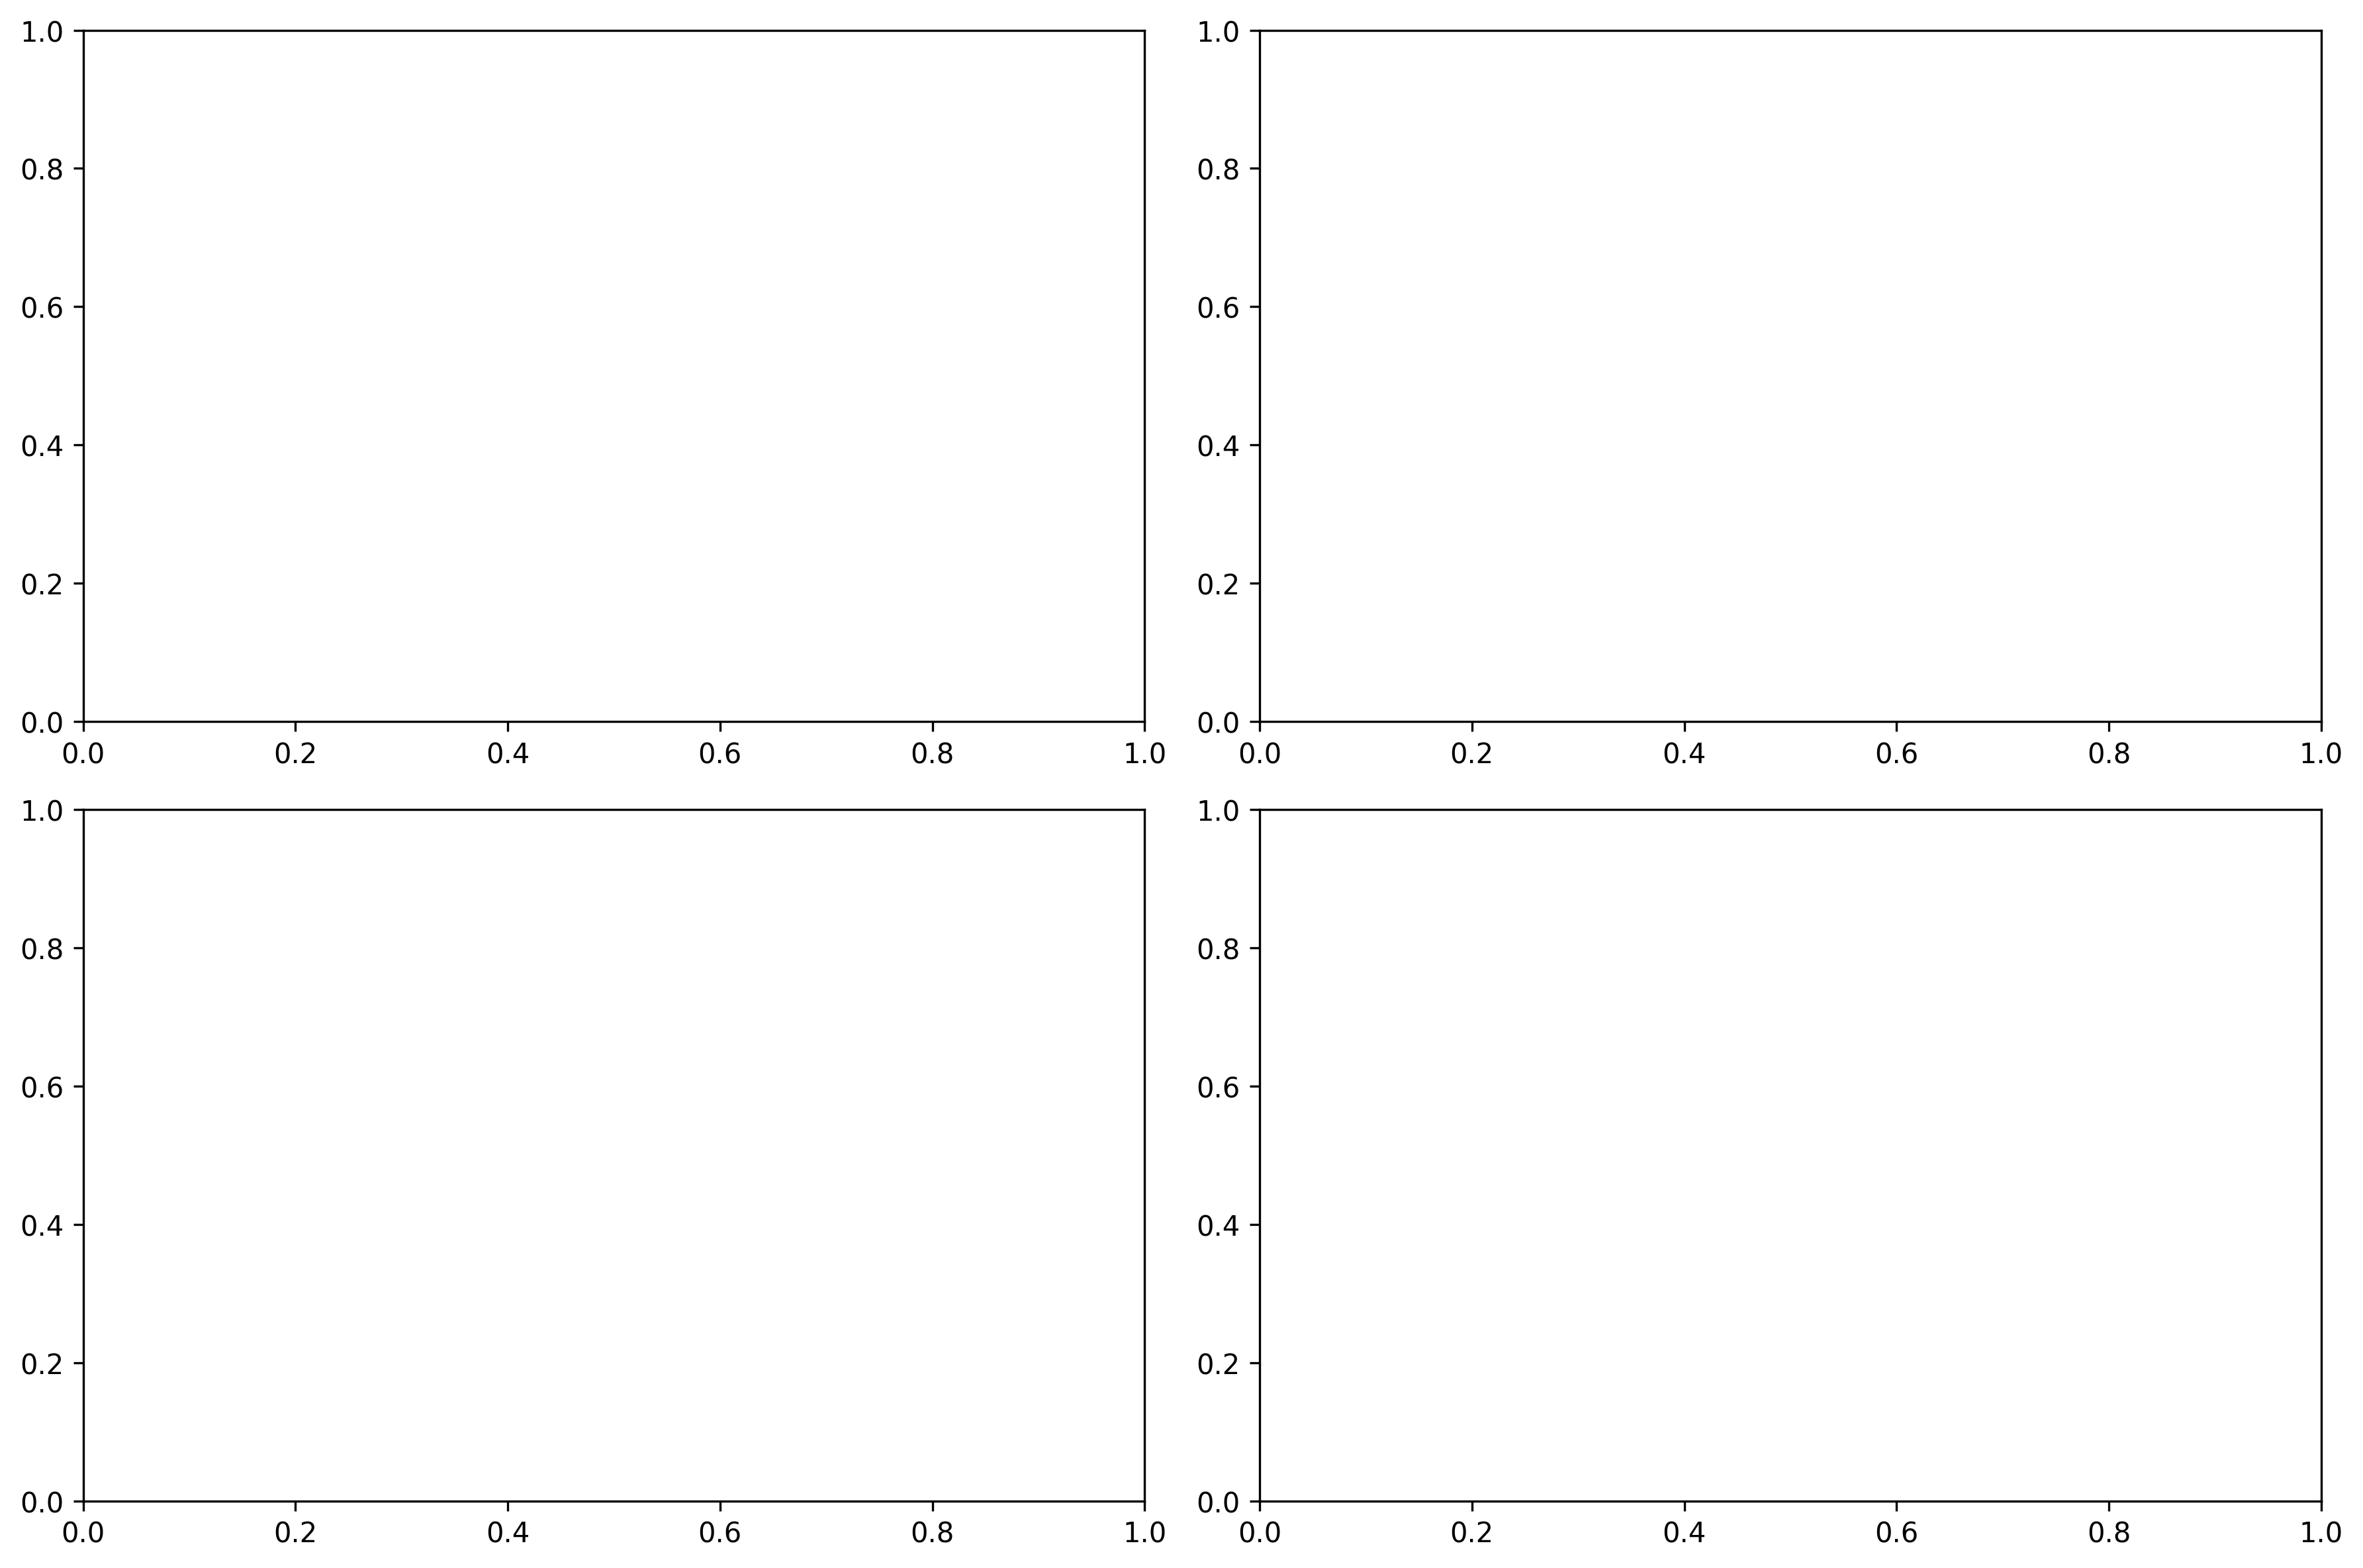

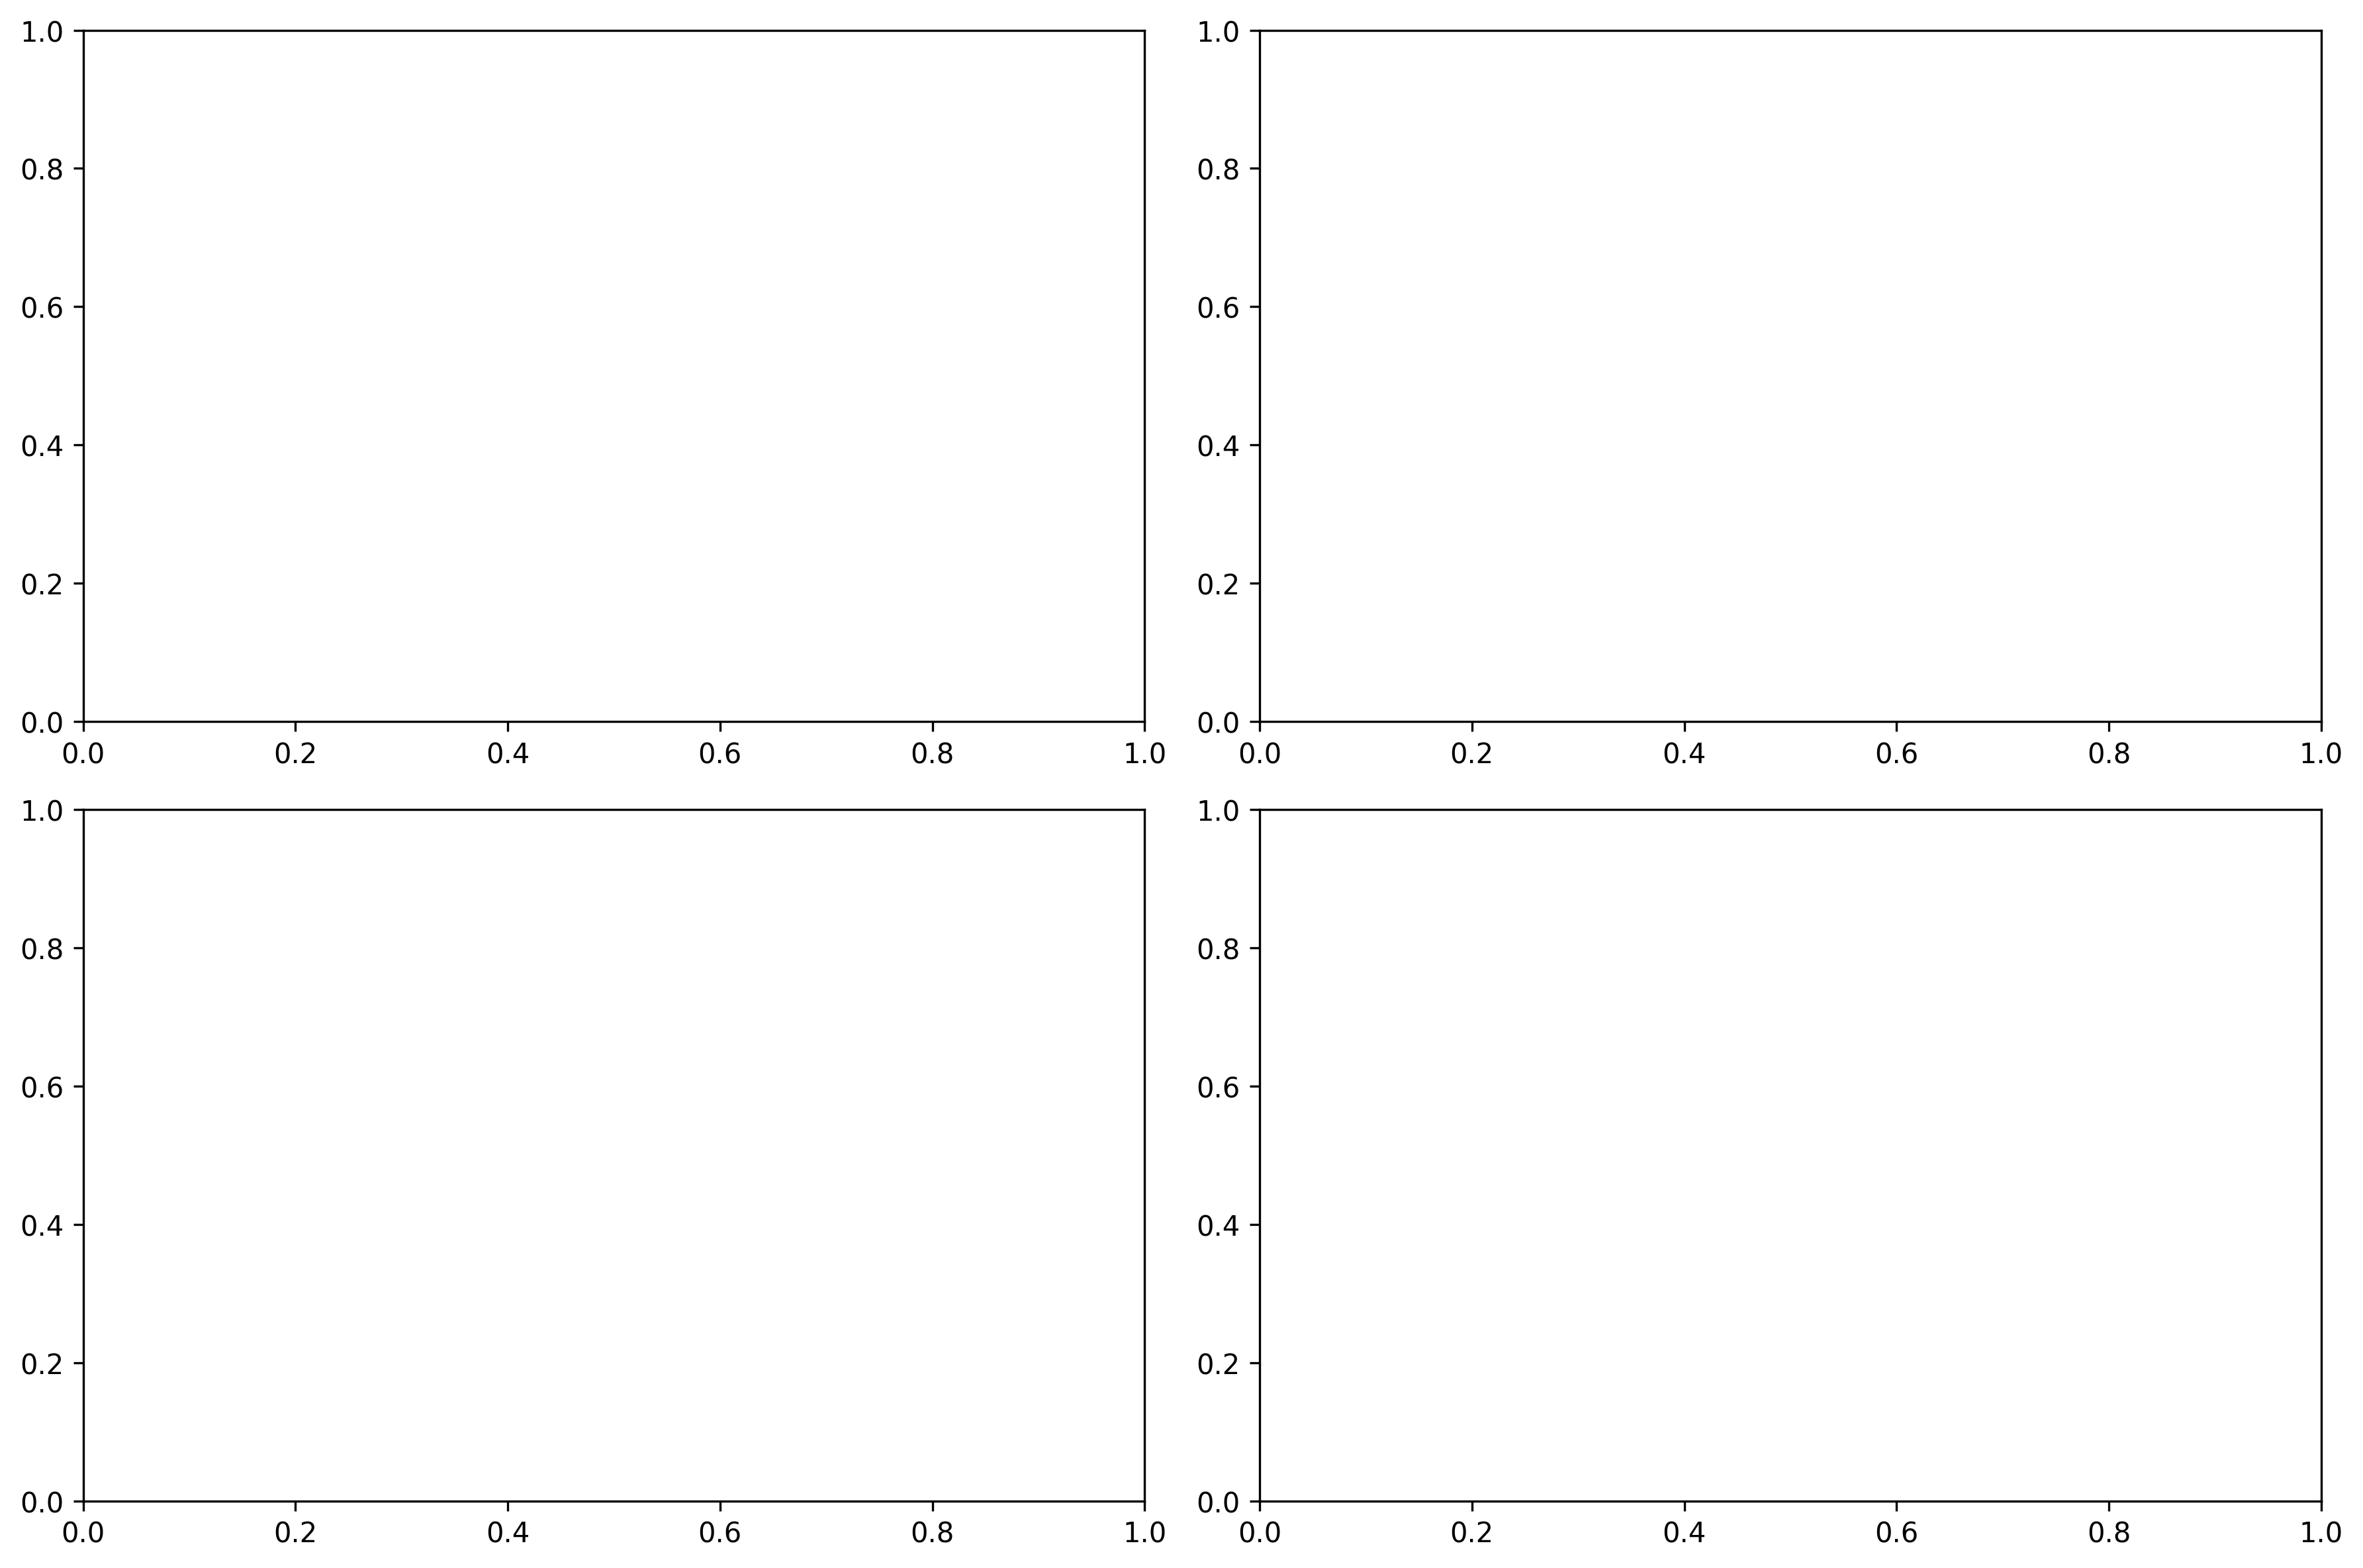

In [24]:
# Draw four together
plt.rcParams['figure.figsize'] = (10, 6)
# Draw non-IID
acc_plt = {}
for num_clients in acc:
    acc_plt[num_clients] = {}
    for partition_type in ['dirichlet']:
        acc_plt[num_clients][partition_type] = {}
        for dirichlet_alpha in acc[num_clients][partition_type][1.0]:
            acc_plt[num_clients][partition_type][dirichlet_alpha] = {}
            for min_ratio_presence in acc[num_clients][partition_type]:
                acc_plt[num_clients][partition_type][dirichlet_alpha][min_ratio_presence] = {}
                for sim_type in acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]:
                    acc_plt[num_clients][partition_type][dirichlet_alpha][min_ratio_presence][sim_type] = {}

for num_clients in acc:
    for partition_type in ["dirichlet"]:
        for min_ratio_presence in acc[num_clients][partition_type]:
            for dirichlet_alpha in acc[num_clients][partition_type][min_ratio_presence]:
                for sim_type in acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]:
                    acc_plt[num_clients][partition_type][dirichlet_alpha][min_ratio_presence][sim_type] = mean_acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type][:199]
                    # print(f"min_ratio_presence:{min_ratio_presence}, dirichlet_alpha:{dirichlet_alpha},sim_type:{sim_type}, len(acc_plt):{len(acc_plt[num_clients][partition_type][dirichlet_alpha][min_ratio_presence][sim_type])}")

for num_clients in acc:
    for partition_type in ["dirichlet"]:
        for dirichlet_alpha in acc_plt[num_clients][partition_type]:
            fig, axes = plt.subplots(2, 2, figsize=(12,8), dpi=300)
            axes = axes.flatten()
            cnt_subplt = 0
            for min_ratio_presence in acc_plt[num_clients][partition_type][dirichlet_alpha]:
                for sim_type in acc_plt[num_clients][partition_type][dirichlet_alpha][min_ratio_presence]:
                    label_texts = {
                        "[DAGFL_GS_alg.]":"DAGFL-FMS",
                        "[DAGFL_RandTips_alg.]-2":"DAGFL-RMS-T2",
                        "[DAGFL_RandTips_alg.]-3":"DAGFL-RMS-T3",
                        "[DAGFL_RandTips_alg.]-4":"DAGFL-RMS-T4",
                        "[DAGFL_RandTips_alg.]-5":"DAGFL-RMS-T5",
                        "[Central_RandOrder]": "ROC-ML",
                        "[Central_Sequential]": "CML",
                        "[Sync_FL]": "Sync_FL",
                        "[Async_FL]": "Async_FL"}
                    linestyles = {
                        "[DAGFL_GS_alg.]":"-.",
                        "[DAGFL_RandTips_alg.]-2":"--",
                        "[DAGFL_RandTips_alg.]-3":"--",
                        "[DAGFL_RandTips_alg.]-4":"--",
                        "[DAGFL_RandTips_alg.]-5":"--",
                        "[Central_RandOrder]": "--",
                        "[Central_Sequential]": "-.",
                        "[Sync_FL]": "-",
                        "[Async_FL]": "-"
                    }
                    if partition_type == 'iid':
                        # title = f"partition: {partition_type}, min_ratio_presence:{min_ratio_presence}"
                        do = 1-min_ratio_presence
                        title = f"Partition: IID, drop-off: {do:.0%}"
                    else:
                        do = 1-min_ratio_presence
                        da_type = {0.1:"strongly non-IID", 0.5:"moderately non-IID", 1.0:"weakly non-IID"}
                        title = f"Partition: {da_type[dirichlet_alpha]}, drop-off: {do:.0%}"
                    y = acc_plt[num_clients][partition_type][dirichlet_alpha][min_ratio_presence][sim_type]
                    if len(y) > 0:
                        x = np.arange(len(y))
                        axes[cnt_subplt].plot(x ,y, linestyle=linestyles[sim_type], label= label_texts[sim_type])  # Default x-values: [0, 1, 2, 3, 4]
                        axes[cnt_subplt].set_title(title)
                        axes[cnt_subplt].set_xlabel("Round",fontsize=8)
                        axes[cnt_subplt].set_ylabel("Accuracy")
                        axes[cnt_subplt].legend()
                cnt_subplt +=1
            plt.tight_layout()
            # plt.legend()
            plt.show()

In [25]:
# # Draw individually
# plt.rcParams['figure.figsize'] = (10, 6)
# for num_clients in acc:
#     for partition_type in acc[num_clients]:
#         for min_ratio_presence in acc[num_clients][partition_type]:
#             for dirichlet_alpha in acc[num_clients][partition_type][min_ratio_presence]:
#                 for sim_type in acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]:
#                     label_texts = {
#                         "[DAGFL_GS_alg.]":"DAGFL-FMS",
#                         "[DAGFL_RandTips_alg.]-2":"DAGFL-RMS-T2",
#                         "[DAGFL_RandTips_alg.]-3":"DAGFL-RMS-T3",
#                         "[DAGFL_RandTips_alg.]-4":"DAGFL-RMS-T4",
#                         "[DAGFL_RandTips_alg.]-5":"DAGFL-RMS-T5",
#                         "[Central_RandOrder]": "ROC-ML",
#                         "[Central_Sequential]": "CML",
#                         "[Sync_FL]": "Sync_FL",
#                         "[Async_FL]": "Async_FL"
#                     }
#                     # markers = {
#                     #     "[DAGFL_RandTips_alg.]-2":"",
#                     #     "[DAGFL_RandTips_alg.]-3":"",
#                     #     "[DAGFL_RandTips_alg.]-4":"",
#                     #     "[DAGFL_RandTips_alg.]-5":"+",
#                     #     "[Central_RandOrder]": "",
#                     #     "[Central_Sequential]": "",
#                     #     "[Sync_FL]": "",
#                     #     "[Async_FL]": ""
#                     # }
#                     linestyles = {
#                         "[DAGFL_GS_alg.]":"-.",
#                         "[DAGFL_RandTips_alg.]-2":"--",
#                         "[DAGFL_RandTips_alg.]-3":"--",
#                         "[DAGFL_RandTips_alg.]-4":"--",
#                         "[DAGFL_RandTips_alg.]-5":"--",
#                         "[Central_RandOrder]": "--",
#                         "[Central_Sequential]": "-.",
#                         "[Sync_FL]": "--",
#                         "[Async_FL]": "--"
#                     }
#                     if partition_type == 'iid':
#                         # title = f"partition: {partition_type}, min_ratio_presence:{min_ratio_presence}"
#                         do = 1-min_ratio_presence
#                         title = f"Partition: IID, drop-off: {do:.0%}"
#                     else:
#                         do = 1-min_ratio_presence
#                         da_type = {0.1:"strongly non-IID", 0.5:"moderately non-IID", 1.0:"weakly non-IID"}
#                         title = f"Partition: {da_type[dirichlet_alpha]}, drop-off: {do:.0%}"
#                         # title = f"Partition: non-IID, D_alpha:{da_type[dirichlet_alpha]}, drop-off: {do:.0%}"
#                         # title = f"partition: {partition_type}, D_alpha:{dirichlet_alpha},min_ratio_presence:{min_ratio_presence}"
#                     y = mean_acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type][:99]
#                     # plt.plot(y, linestyle=linestyles[sim_type], marker=markers[sim_type],label= label_texts[sim_type])  # Default x-values: [0, 1, 2, 3, 4]
#                     plt.plot(y, linestyle=linestyles[sim_type], label= label_texts[sim_type])  # Default x-values: [0, 1, 2, 3, 4]
#                 plt.legend()
#                 plt.title(title)
#                 plt.xlabel("Round")
#                 plt.ylabel("Accuracy")
#                 plt.show()


In [26]:
# for num_clients in acc:
#     for partition_type in acc[num_clients]:
#         for min_ratio_presence in acc[num_clients][partition_type]:
#             for dirichlet_alpha in acc[num_clients][partition_type][min_ratio_presence]:
#                 for sim_type in acc[num_clients][partition_type][min_ratio_presence][dirichlet_alpha]:
#                     label = sim_type
#                     if partition_type == 'IID':
#                         title = f"partition: {partition_type}, min_ratio_presence:{min_ratio_presence}"
#                     else:
#                         title = f"partition: {partition_type}, D_alpha:{dirichlet_alpha},min_ratio_presence:{min_ratio_presence}"
#                     y = mean_loss[num_clients][partition_type][min_ratio_presence][dirichlet_alpha][sim_type]
#                     plt.plot(y, label= label)  # Default x-values: [0, 1, 2, 3, 4]
#                 plt.legend()
#                 plt.title(title)
#                 plt.show()
